# LASSO回归分析

## $\S1$ Configuration & Data Preparation

In [10]:
# Configuration
## Loading Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


## Data Path
Path = "./Raw_Data_3.xlsx"
Dependent_Variable = "USD_index_Close"

## Param Grid
param_grid = {
    "model__alpha": np.logspace(-3, 3, 100)
}

## CV Scoring
scoring = {
    ### sklearn默认maximize the score, so we use prefix "neg"
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}


In [11]:
# Data Preparation
## Loading Data
Data = pd.read_excel(Path, index_col="日期")
print("Data Size:", Data.shape)

## Data Split & Scale
### Split Features and Label
X = Data.drop(columns=[Dependent_Variable])
y = Data[[Dependent_Variable]]
# X,y = X.values, y.values

Data Size: (3420, 30)


In [12]:
### Split Train, Valid and Test Sets
train_size = int(len(Data) * 0.8)
X_train, X_test = X.iloc[:train_size, :], X.iloc[train_size:, :]
y_train, y_test = y.iloc[:train_size, :], y.iloc[train_size:, :]

#### Split Train Set into Tims Series
tsCV = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tsCV.split(X_train)):
    print(f"Fold {fold}: Train {len(train_idx)}, Test {len(test_idx)}")


Fold 0: Train 456, Test 456
Fold 1: Train 912, Test 456
Fold 2: Train 1368, Test 456
Fold 3: Train 1824, Test 456
Fold 4: Train 2280, Test 456


## $\S2$ Model Training & Predicting

In [13]:
## Generating Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=42)),
]
)

## Model Selection
### Grid_Search with Pipe on Grid using TimeSeriesSplit CV on Train Set
gsCV = GridSearchCV(
    estimator = pipe,
    param_grid=param_grid,
    cv = tsCV,
    scoring = scoring,
    refit = "R2",
    n_jobs = -1,
    verbose = 2
)
gsCV.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,{'model__alpha': array([1.0000...00000000e+03])}
,scoring,"{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,n_jobs,-1
,refit,'R2'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [14]:
### printing best model
#### Best Hyper Parameters:
print("Grid Search 最佳参数: ", gsCV.best_params_)
print("对应的(CV平均)最优R2:", gsCV.best_score_)

#### CV Results:
result = pd.DataFrame(gsCV.cv_results_)
cols_to_show = ["param_model__alpha", "mean_test_RMSE", "mean_test_MAE", "mean_test_R2"]
result["mean_test_MAE"] = -result["mean_test_MAE"]
result["mean_test_RMSE"] = -result["mean_test_RMSE"]
print(result[cols_to_show].sort_values(by="mean_test_R2", ascending=False).head(10))

Grid Search 最佳参数:  {'model__alpha': np.float64(497.7023564332114)}
对应的(CV平均)最优R2: -0.8397042260209024
    param_model__alpha  mean_test_RMSE  mean_test_MAE  mean_test_R2
94          497.702356        0.001793       0.001431     -0.839704
93          432.876128        0.001791       0.001431     -0.840408
95          572.236766        0.001796       0.001432     -0.840600
96          657.933225        0.001799       0.001433     -0.842737
92          376.493581        0.001788       0.001431     -0.843024
97          756.463328        0.001801       0.001435     -0.845728
91          327.454916        0.001787       0.001432     -0.847812
98          869.749003        0.001804       0.001437     -0.849159
99         1000.000000        0.001806       0.001440     -0.852608
90          284.803587        0.001785       0.001433     -0.854969


In [15]:
## Model Prediction
### 在gsCV中，refit已经选取了最优模型，Pipe在整个训练集上进行了重新训练
best_ridge = gsCV.best_estimator_
best_ridge.named_steps["model"].alpha
y_pred = best_ridge.predict(X_test)

Text(0.5, 1.0, 'LASSO Regression Prediction')

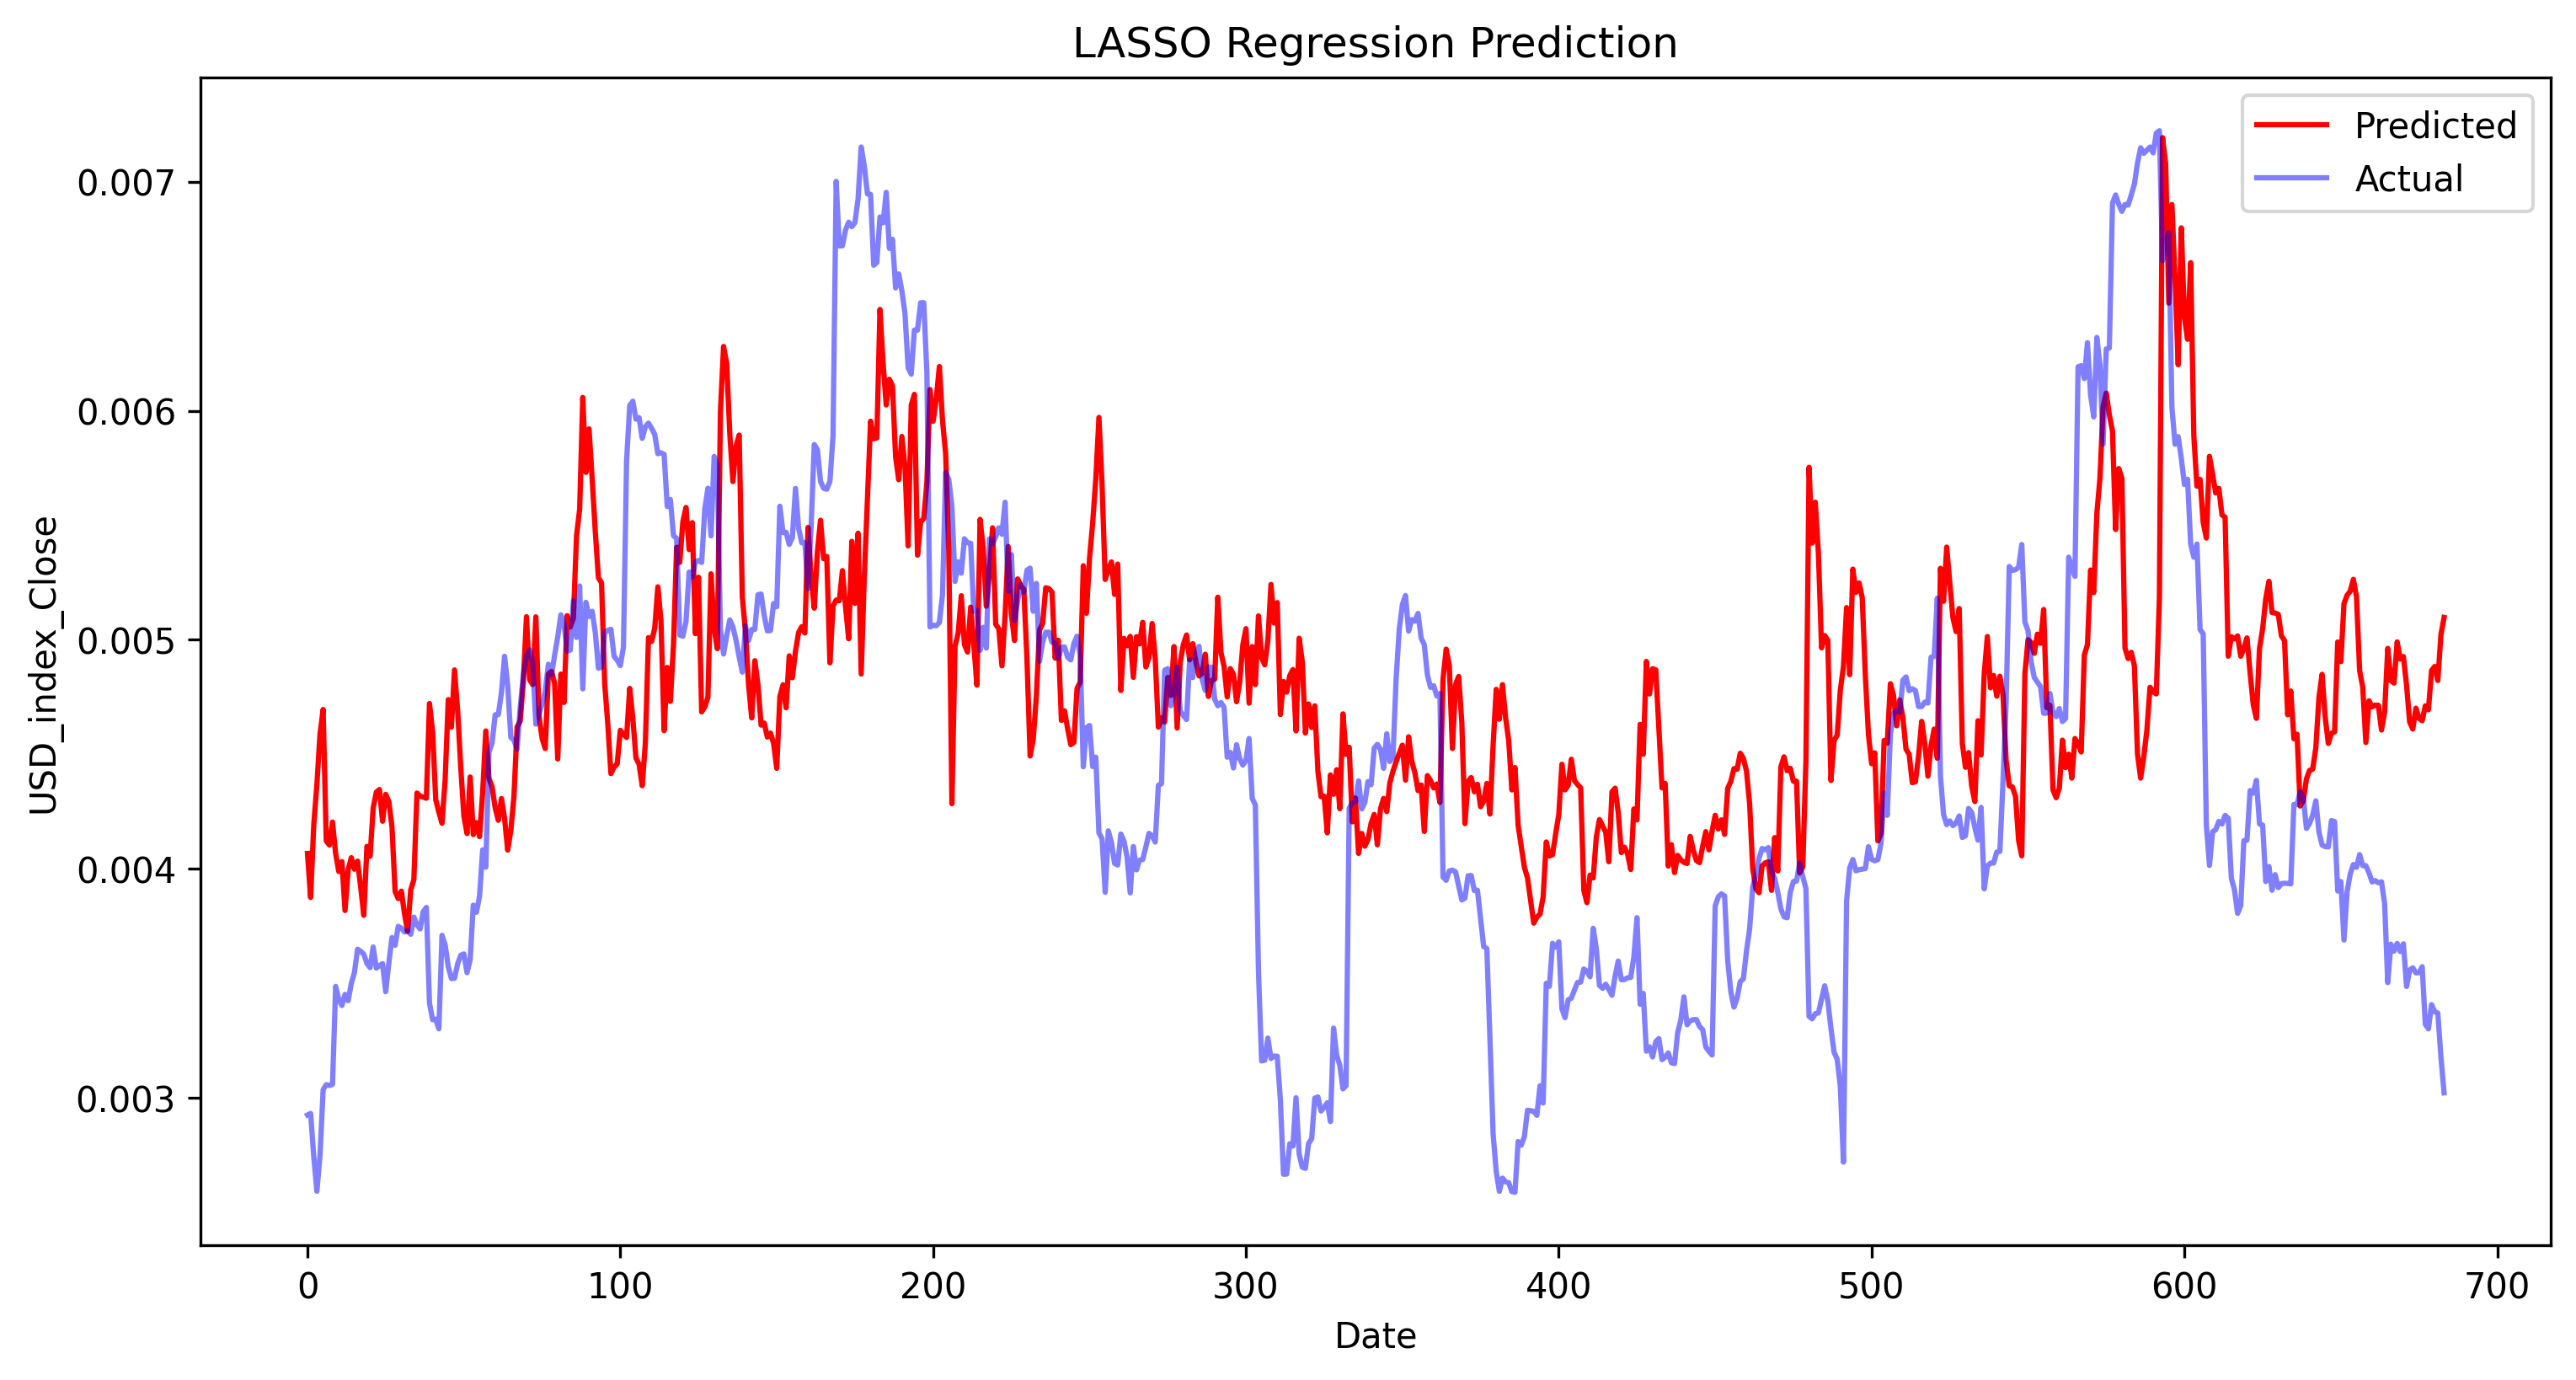

In [16]:
### Prediction Visualization
fig, ax1 = plt.subplots(figsize=(12,6), dpi=300)
ax1.plot(y_pred, label="Predicted", color="red")
ax1.plot(y_test.values, label="Actual", color="blue", alpha=0.5)
ax1.set_xlabel("Date")
ax1.set_ylabel("USD_index_Close")
ax1.legend()
ax1.set_title("LASSO Regression Prediction")

## $\S3$ Model Evaluation & Explanation

In [17]:
## Model Evaluation
# 4.2 计算测试集指标
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("=== 测试集表现 ===")
print(f"MAE  : {test_mae:.6f}")
print(f"RMSE  : {test_rmse:.6f}")
print(f"R^2  : {test_r2:.6f}")

=== 测试集表现 ===
MAE  : 0.000760
RMSE  : 0.000941
R^2  : 0.189947


In [18]:
best_ridge.named_steps["model"].coef_

array([-1.15550552e-05,  1.46985419e-05,  1.67902374e-05,  4.94273513e-05,
        2.22407542e-05, -3.06118415e-05, -8.69596846e-05, -1.23981548e-04,
        7.15388220e-06, -9.46537937e-05,  7.92222961e-06,  4.92176383e-04,
        1.05720935e-05,  1.13888566e-05,  2.22152460e-07,  3.61199425e-06,
        2.12293892e-05, -3.57730636e-05, -1.24106678e-04, -1.59322549e-04,
       -4.90958375e-05, -4.75069796e-05, -5.09181922e-05,  5.95955303e-06,
        6.75361570e-06,  7.60588440e-05,  8.31272685e-05,  2.69250705e-06,
        4.50789487e-04])